# 匯入套件

In [1]:
import pandas as pd
import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 視覺化分類機率分布

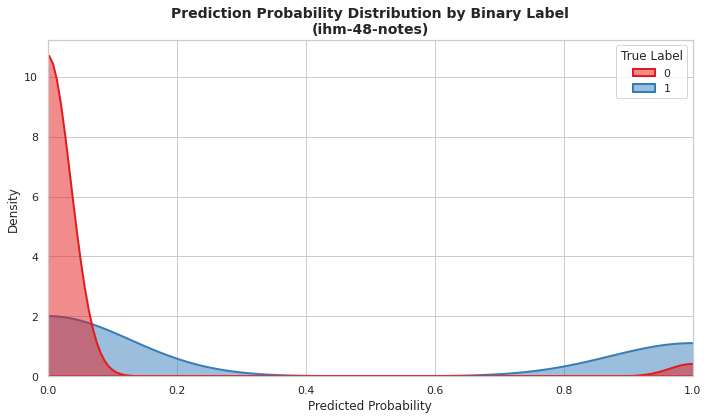

In [2]:
task = 'ihm-48-notes'
filepath = f"/mnt/data/yihua/master/implementations/FuseMoE/src/run/TS_Text/{task}_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512"

with open(os.path.join(filepath, 'sample_result.pkl'), 'rb') as f:
    result = pickle.load(f)

# 取樣數量（依據你原本的設定，取 1/5 的資料）
num_sample = result['features'].shape[0]
sample_size = num_sample // 5

# 確保 labels 與 preds 的數量一致且變成一維陣列
labels = result['labels'][:sample_size].flatten()
preds = result['preds'][:sample_size].flatten()

# --- 新增：視覺化預測機率分布 ---

# 1. 建立 DataFrame 方便 Seaborn 處理
df_plot = pd.DataFrame({
    'Predicted Probability': preds,
    'True Label': labels
})

# 2. 設定繪圖風格與畫布
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. 繪製機率密度圖 (KDE Plot)
# common_norm=False 可以讓正負樣本各自歸一化，避免因為樣本不均衡導致某一邊的圖形太矮
sns.kdeplot(
    data=df_plot, 
    x='Predicted Probability', 
    hue='True Label', 
    fill=True, 
    common_norm=False, 
    palette='Set1', 
    alpha=0.5, 
    linewidth=2
)

# 4. 調整圖表細節
plt.title(f'Prediction Probability Distribution by Binary Label\n({task})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)  # 二元分類機率範圍在 0 到 1 之間

# 5. 顯示或儲存圖表
plt.tight_layout()
plt.savefig(os.path.join(filepath, 'images', 'preds_distribution.png'))
plt.show()